In [1]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import h3
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
import mapclassify
from shapely import Polygon
import shapely
import contextily
from shapely.geometry import box
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

In [2]:
NOTEBOOK_PATH = Path().resolve()
DATA_DIR = NOTEBOOK_PATH / 'data'
MAPS_DIR = NOTEBOOK_PATH / "maps"
ASSETS_DIR =  NOTEBOOK_PATH / "assets"
MAPS_DIR.mkdir(exist_ok=True)
ASSETS_DIR.mkdir(exist_ok=True)

In [3]:
mobility_gdf = gpd.read_file(DATA_DIR / "erasmus_mobility_datasets.gpkg", layer='2018_student_mobility_NUTS2')
mobility_gdf.head()

,OD_ID,ORIGIN,DESTINATION,geometry
0,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
1,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1..."
2,AL01_ITG2,AL01,ITG2,"LINESTRING (5147813.725 2147741.583, 4237843.6..."
3,AL02_AT31,AL02,AT31,"LINESTRING (5166646.306 2059058.198, 4616056.5..."
4,AL02_DE12,AL02,DE12,"LINESTRING (5166646.306 2059058.198, 4224282.2..."


In [4]:
europe_gdf = gpd.read_file(DATA_DIR / "europe_borders.zip").to_crs(mobility_gdf.crs)
europe_gdf.head()

,GID_0,COUNTRY,geometry
0,ALB,Albania,"MULTIPOLYGON (((5185353.594 1901653.12, 518399..."
1,BEL,Belgium,"MULTIPOLYGON (((3992762.882 2941912.743, 39926..."
2,BGR,Bulgaria,"MULTIPOLYGON (((5583297.05 2151545.861, 558324..."
3,HRV,Croatia,"MULTIPOLYGON (((4878690.154 2207591.579, 48787..."
4,CYP,Cyprus,"MULTIPOLYGON (((6466798.95 1664346.442, 646742..."


In [5]:
starts = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[0])))
ends   = gpd.GeoDataFrame(mobility_gdf.copy(), geometry=mobility_gdf.geometry.apply(lambda g: Point(g.coords[-1])))

starts_in = gpd.sjoin(starts, europe_gdf, predicate="within")
ends_in   = gpd.sjoin(ends, europe_gdf, predicate="within")

valid_ids = set(starts_in.index) & set(ends_in.index)

mobility_europe = mobility_gdf.loc[list(valid_ids)]

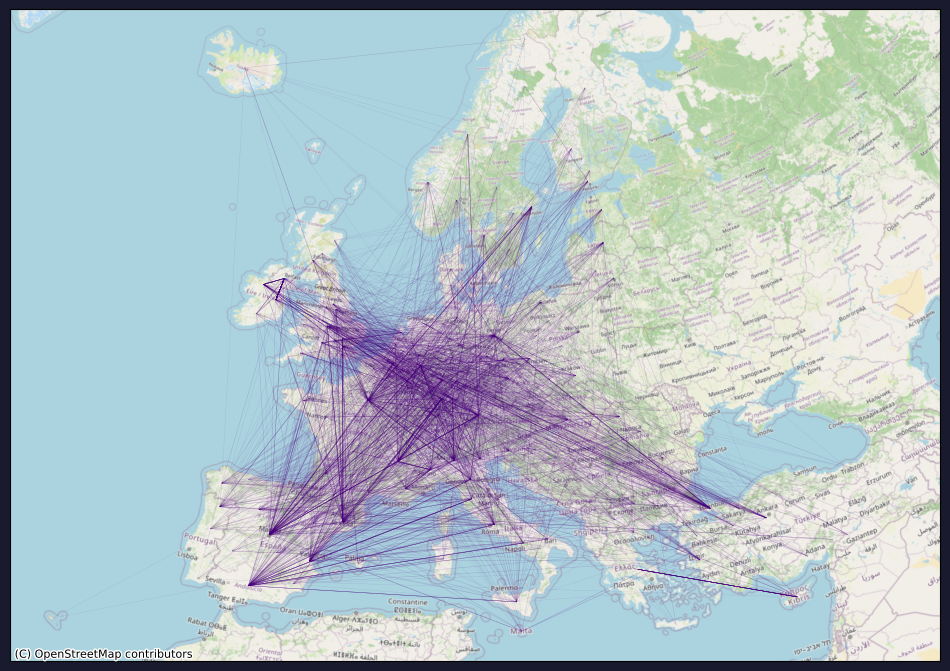

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='#1a1a2e')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

mobility_europe.plot(ax = ax, color="indigo", linewidth=0.3, alpha=0.1)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=5,
    alpha=1
)

# plt.savefig(ASSETS_DIR / "exploratory_map.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Lengths

In [6]:
mobility_europe["length_km"] = mobility_europe.geometry.length / 1000

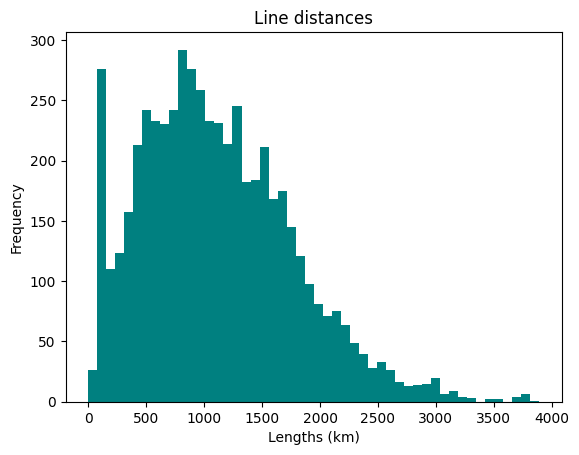

In [ ]:
plt.hist(mobility_europe["length_km"], color="teal", bins=50)
plt.xlabel("Lengths (km)")
plt.ylabel("Frequency")
plt.title("Line distances")

# plt.savefig(ASSETS_DIR / "distances_hist.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
fig = px.histogram(mobility_europe,
                   x='length_km',
                   nbins=50, 
                   color_discrete_sequence=['teal'])  

fig.update_traces(
    hovertemplate='Lengths: %{x} km<br>Count: %{y}<extra></extra>'
)

fig.update_layout(
    xaxis_title='Lengths (km)',
    yaxis_title='Frequency',
    bargap=0.2, 
    title=dict(
        text="Line Distances",
        x=0.5,
        font=dict(size=24)
    ),
    dragmode=False,
    xaxis_fixedrange=True,
    yaxis_fixedrange=True,
    paper_bgcolor="whitesmoke"
)

fig.show(config={"displayModeBar": False})
# fig.write_html(ASSETS_DIR / "distances_interactive_hist.html", config={"displayModeBar": False})

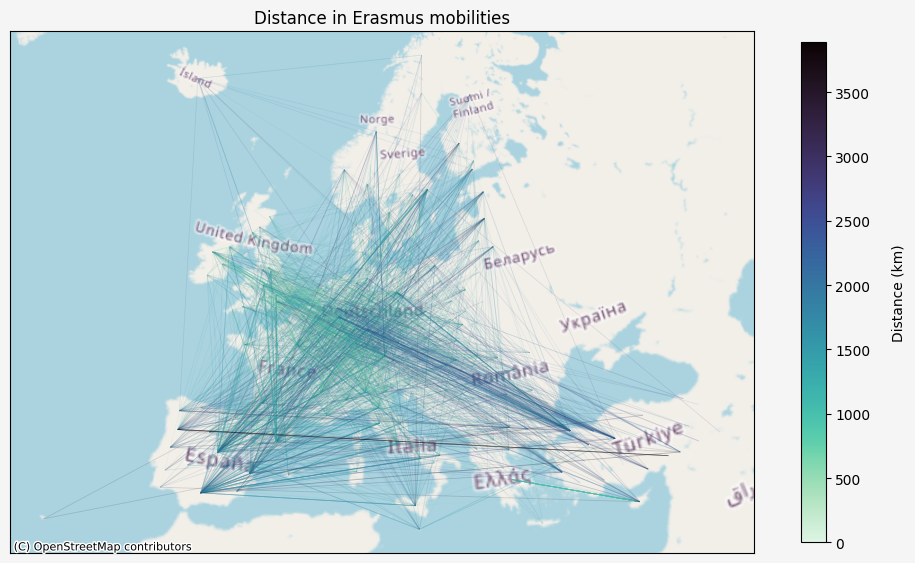

In [ ]:
fig, ax = plt.subplots(figsize=(12, 13), facecolor='whitesmoke')

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

vals = mobility_europe["length_km"]
vals = vals.clip(lower=1e-6)
vmin, vmax = vals.min(), vals.max()
alphas = 0.05 + (vals - vmin) / (vmax - vmin) * (0.15 - 0.05)

norm = (vals - vals.min()) / (vals.max() - vals.min())
lw = 0.1 + (norm ** 0.2) * (0.6 - 0.1) 

mobility_europe.plot(
    ax = ax,
    column="length_km",
    cmap=sns.color_palette("mako_r", as_cmap=True),
    linewidth=lw,
    alpha=alphas,
    legend=True,
    legend_kwds={ "shrink": 0.5}
)
cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Distance (km)", rotation=90, labelpad=15)

contextily.add_basemap(
    ax,
    source=contextily.providers.OpenStreetMap.Mapnik,
    crs=mobility_europe.crs,
    zoom=3,
    alpha=1
)

plt.title("Distance in Erasmus mobilities")
# plt.savefig(MAPS_DIR / "distances_km.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### Countries

In [19]:

mobility_europe["origin_point"]      = mobility_europe.geometry.apply(lambda l: Point(l.coords[0]))
mobility_europe["destination_point"] = mobility_europe.geometry.apply(lambda l: Point(l.coords[-1]))

origin_gdf = gpd.GeoDataFrame(mobility_europe[["OD_ID"]], geometry=mobility_europe["origin_point"], crs=mobility_europe.crs)
dest_gdf   = gpd.GeoDataFrame(mobility_europe[["OD_ID"]], geometry=mobility_europe["destination_point"], crs=mobility_europe.crs)

origin_joined = gpd.sjoin(origin_gdf, europe_gdf[["COUNTRY", "geometry"]], how="left", predicate="within")
dest_joined   = gpd.sjoin(dest_gdf,   europe_gdf[["COUNTRY", "geometry"]], how="left", predicate="within")

origin_countries = origin_joined[~origin_joined.index.duplicated(keep="first")]["COUNTRY"].reindex(mobility_europe.index)
dest_countries   = dest_joined[~dest_joined.index.duplicated(keep="first")]["COUNTRY"].reindex(mobility_europe.index)

mobility_europe["origin_country"]      = origin_countries.values
mobility_europe["destination_country"] = dest_countries.values
mobility_europe.head()

,OD_ID,ORIGIN,DESTINATION,geometry,length_km,origin_point,destination_point,origin_country,destination_country
0,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1...",1523.202437,POINT (5147813.725 2147741.583),POINT (4171381.181 3316811.792),Albania,Germany
1,AL01_DE94,AL01,DE94,"LINESTRING (5147813.725 2147741.583, 4171381.1...",1523.202437,POINT (5147813.725 2147741.583),POINT (4171381.181 3316811.792),Albania,Germany
2,AL01_ITG2,AL01,ITG2,"LINESTRING (5147813.725 2147741.583, 4237843.6...",946.252729,POINT (5147813.725 2147741.583),POINT (4237843.643 1888225.346),Albania,Italy
4,AL02_DE12,AL02,DE12,"LINESTRING (5166646.306 2059058.198, 4224282.2...",1249.425540,POINT (5166646.306 2059058.198),POINT (4224282.254 2879432.609),Albania,Germany
5,AL02_DE40,AL02,DE40,"LINESTRING (5166646.306 2059058.198, 4552249.1...",1355.720574,POINT (5166646.306 2059058.198),POINT (4552249.195 3267567.39),Albania,Germany


In [ ]:
import plotly.graph_objects as go

country_counts = mobility_europe["origin_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
total = country_counts["count"].sum()

top15 = country_counts.head(15).copy()
others = country_counts.iloc[15:].copy()

other_row = pd.DataFrame([{
    "country": "Other",
    "count": others["count"].sum(),
}])
other_countries_list = "<br>".join(others["country"].tolist()) 

final = pd.concat([top15, other_row], ignore_index=True) 
final["pct"] = (final["count"] / total * 100).round(2)

hover = []
for _, row in final.iterrows():
    if row["country"] == "Other":
        hover.append(
            f"<b>Other countries</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%<br><br>"
            f"<i>{other_countries_list}</i>"
        )
    else:
        hover.append(
            f"<b>{row['country']}</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%"
        )
        
viridis = px.colors.get_colorscale("Viridis")
greens = px.colors.sample_colorscale("Viridis", [i/16 for i in range(16)], colortype="rgb")

fig = go.Figure(go.Pie(
    labels=final["country"],
    values=final["count"],
    hovertemplate="%{customdata}<extra></extra>",
    customdata=hover,
    textinfo="none",
    hole=0.3,
    sort=False,
    marker=dict(colors=greens),
    rotation=-29, 
    direction="clockwise"
))

fig.update_layout(
    title=dict(text="Erasmus Mobility by Origin Country", x=0.5, xanchor="center", font=dict(size=28, family="Georgia")),
    legend=dict(orientation="v", x=1.05, y=0.5, font=dict(size=16)),
    hoverlabel=dict(bgcolor="white", font_size=16, namelength=-1),
    width=900,
    height=700,
    modebar=dict(remove=["all"]),
    paper_bgcolor="whitesmoke",
)

fig.show()
# fig.write_html(ASSETS_DIR / "origin_country_pie.html", config={"displayModeBar": False})

In [ ]:
import plotly.graph_objects as go

country_counts = mobility_europe["destination_country"].value_counts().reset_index()
country_counts.columns = ["country", "count"]
total = country_counts["count"].sum()

top15 = country_counts.head(15).copy()
others = country_counts.iloc[15:].copy()

other_row = pd.DataFrame([{
    "country": "Other",
    "count": others["count"].sum(),
}])
other_countries_list = "<br>".join(others["country"].tolist()) 

final = pd.concat([top15, other_row], ignore_index=True) 
final["pct"] = (final["count"] / total * 100).round(2)

hover = []
for _, row in final.iterrows():
    if row["country"] == "Other":
        hover.append(
            f"<b>Other countries</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%<br><br>"
            f"<i>{other_countries_list}</i>"
        )
    else:
        hover.append(
            f"<b>{row['country']}</b><br>"
            f"Students: {int(row['count'])}<br>"
            f"Share: {row['pct']}%"
        )
        
viridis = px.colors.get_colorscale("Viridis")
greens = px.colors.sample_colorscale("Viridis", [i/16 for i in range(16)], colortype="rgb")

fig = go.Figure(go.Pie(
    labels=final["country"],
    values=final["count"],
    hovertemplate="%{customdata}<extra></extra>",
    customdata=hover,
    textinfo="none",
    hole=0.3,
    sort=False,
    marker=dict(colors=greens),
    rotation=-56, 
    direction="clockwise"
))

fig.update_layout(
    title=dict(text="Erasmus Mobility by Destination Country", x=0.5, xanchor="center", font=dict(size=28, family="Georgia")),
    legend=dict(orientation="v", x=1.05, y=0.5, font=dict(size=16)),
    hoverlabel=dict(bgcolor="white", font_size=16, namelength=-1),
    width=900,
    height=700,
    modebar=dict(remove=["all"]),
    paper_bgcolor="whitesmoke",
)

fig.show()
# fig.write_html(ASSETS_DIR / "destination_country_pie.html", config={"displayModeBar": False})